<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 7, Forecasting Probabilístico y Modelado de Incertidumbre**

Dataset **demanda diaria de bicicletas** (Capital Bikeshare, Washington DC, 2011–2012). 731 días. Hay que decidir cuántas unidades tener disponibles
sabiendo que la demanda es incierta.

Modelo: **Chronos-2** en zero-shot.

---

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

Importamos lo necesario y visualizamos la demanda diaria de bicicletas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

plt.rcParams["figure.figsize"] = (11, 3.6)

In [ ]:
URL = ("https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/"
       "master/project-bikesharing/Bike-Sharing-Dataset/day.csv")

* Descargamos el CSV sobre demanda diaria de bicicletas.
* Le cambiamos nombres de columnas para que quede en el formato de Chronos-2: item_id (identificador de la serie, acá siempre bicicletas porque es una sola serie), timestamp (la fecha) y target (el valor a predecir, la cantidad de bicicletas alquiladas ese día).

In [ ]:
raw = pd.read_csv(URL, parse_dates=["dteday"])
df = (raw.rename(columns={"dteday": "timestamp", "cnt": "target"})
         .assign(item_id="bicis")[["item_id", "timestamp", "target"]])

731 dias | 2011-01-01 -> 2012-12-31
demanda diaria: media 4504 | min 22 | max 8714


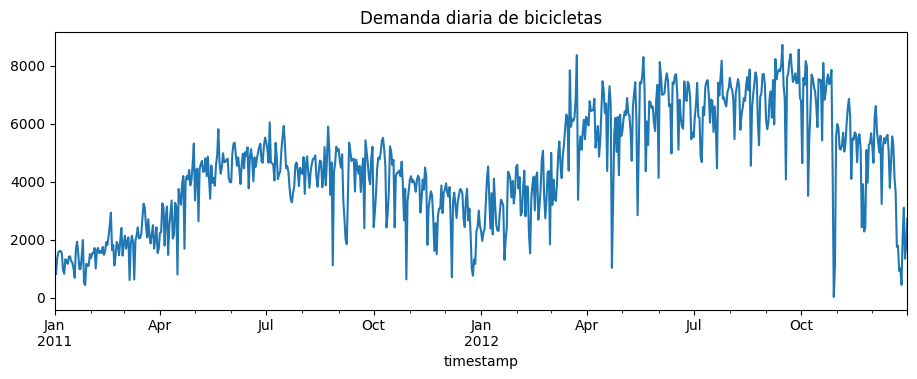

In [ ]:
print(f"{len(df)} dias | {df.timestamp.min().date()} -> {df.timestamp.max().date()}")
print(f"demanda diaria: media {df.target.mean():.0f} | min {df.target.min()} | max {df.target.max()}")
df.set_index("timestamp").target.plot(title="Demanda diaria de bicicletas");

Tenemos 731 observaciones diarias, cubriendo dos años completos. La demanda promedio ronda las 4500 bicicletas/día, pero varía mucho: hay días con solo 22 (probablemente una tormenta de nieve) y días con casi 8714 (un día pico de verano). Esa variabilidad tan grande es exactamente la razón por la que interesa modelar incertidumbre y no solo un número promedio.


## A) Un pronóstico probabilístico, sin entrenar nada

Chronos-2 devuelve un número por nivel, no un número solo.

In [ ]:
from chronos import Chronos2Pipeline

H  = 7                                            # horizonte: 7 dias
QL = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # los niveles que queremos
QC = [str(q) for q in QL]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

* Le damos al modelo todos los datos menos los últimos 7 días (df.iloc[:-H]), y le pedimos que prediga esos 7 días hacia adelante.
* Le pedimos 9 cuantiles (0.1 a 0.9) en vez de un solo número.

In [ ]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

pred = pipe.predict_df(
    df.iloc[:-H], # todo menos la ultima semana
    prediction_length=H,
    quantile_levels=QL,
    id_column="item_id", timestamp_column="timestamp", target="target",
)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

* Cada fila es un día futuro, y las columnas 0.1, 0.5, 0.9 nos dan, para ese día: el valor por debajo del cual el modelo cree que caerá la demanda el 10% de las veces (0.1), el valor central esperado (0.5), y el valor por debajo del cual caerá el 90% de las veces (0.9).
* Por ejemplo, si un día muestra 0.1=3200, 0.5=4100, 0.9=5300, el modelo está diciendo: "espero unas 4100 bicicletas, pero podría ser tan poco como 3200 o tanto como 5300, y estoy bastante seguro (80% de confianza) de que va a caer en ese rango".

In [ ]:
pred["timestamp"] = pd.to_datetime(pred["timestamp"])
pred[["timestamp", "0.1", "0.5", "0.9"]].round(0)

,timestamp,0.1,0.5,0.9
0,2012-12-25,291.0,2035.0,3692.0
1,2012-12-26,1161.0,3344.0,5074.0
2,2012-12-27,1543.0,3870.0,5536.0
3,2012-12-28,1776.0,4075.0,5651.0
4,2012-12-29,1756.0,4067.0,5635.0
5,2012-12-30,1714.0,4025.0,5597.0
6,2012-12-31,1770.0,4119.0,5621.0


`0.5` es la mediana. `0.1` y `0.9` arman el rango donde esperamos caer 8 de cada 10 veces.

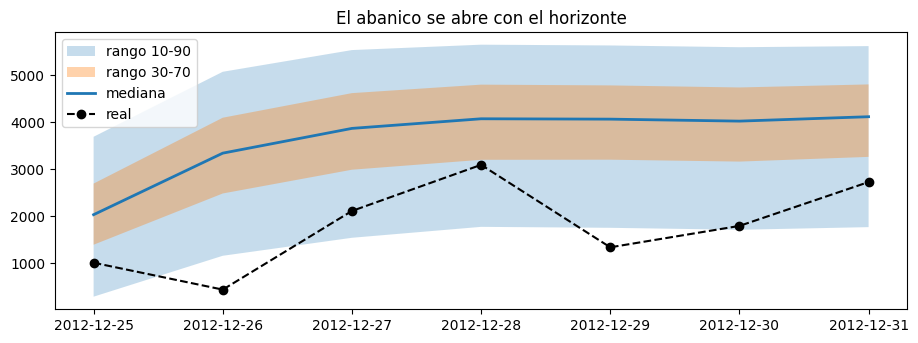

In [ ]:
real = df.tail(H)
x = pred.timestamp.values
plt.fill_between(x, pred["0.1"], pred["0.9"], alpha=.25, label="rango 10-90")
plt.fill_between(x, pred["0.3"], pred["0.7"], alpha=.35, label="rango 30-70")
plt.plot(x, pred["0.5"], lw=2, label="mediana")
plt.plot(real.timestamp.values, real.target.values, "ko--", label="real")
plt.legend(); plt.title("La distribución se abre con el horizonte");

Si tuviera ancho constante, el modelo no estaría modelando incertidumbre, estaría repitiendo un número.


## B) ¿Los niveles salen ordenados?

El nivel 10 nunca puede quedar por encima del nivel 50. Pero nada en la arquitectura lo obliga.

Tomamos la matriz de cuantiles predichos y compara cada columna con la anterior. Como los niveles van de menor a mayor (0.1, 0.2, ..., 0.9), el valor del cuantil 0.2 debería ser siempre mayor o igual al del cuantil 0.1, y así sucesivamente. Esta línea cuenta cuántas veces eso no se cumple (un "cruce").

In [ ]:
Q = pred[QC].values
cruces = (Q[:, 1:] < Q[:, :-1]).sum()
print(f"cruces: {cruces} de {Q[:, 1:].size} comparaciones")

cruces: 0 de 56 comparaciones


Chronos-2, al estar entrenado específicamente con una cabeza de predicción de cuantiles conjunta, casi nunca viola el orden lógico.

Un modelo casero con 9 salidas independientes (una red por cuantil, sin coordinación entre ellas) si tendría más cruces, especialmente en los cuantiles extremos y en horizontes lejanos, porque nada en su arquitectura les impide pisarse.

In [ ]:
Q_ok = np.sort(Q, axis=1) # el arreglo: una linea
print("despues de ordenar:", (Q_ok[:, 1:] < Q_ok[:, :-1]).sum())

despues de ordenar: 0


**Usar los niveles para responder preguntas de negocio:**

* Esta función convierte los 9 cuantiles discretos en una función continua aproximada, interpolando.
* Si le pedimos ¿qué probabilidad hay de superar 4000 bicis?, busca dónde caería 4000 entre los cuantiles conocidos y estima qué percentil representa, y con eso calcula la probabilidad de estar por encima.

In [ ]:
def prob_superar(fila, umbral):
    return 1 - np.interp(umbral, fila[QC].values.astype(float), QL)

In [ ]:
dia = pred.iloc[0]
for u in [3000, 4000, 5000]:
    print(f"P(demanda > {u}) = {prob_superar(dia, u):.0%}")

P(demanda > 3000) = 23%
P(demanda > 4000) = 10%
P(demanda > 5000) = 10%


*Hay 55% de chance de necesitar más de 4000 bicis mañana*

---
## C) MC Dropout

Chronos-2 ya viene probabilístico. ¿Y si tenemos una red normal que devuelve un solo número?

El truco: dejar el dropout **prendido** en inferencia y correr N veces.

In [ ]:
import torch
import torch.nn as nn

class RedSimple(nn.Module):
    # Recibe 28 números (los últimos 28 días de demanda, normalizados) y devuelve
    # 7 números (la predicción de los próximos 7 días).
    def __init__(self, entrada=28, oculta=64, salida=7):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(entrada, oculta),
                                 nn.ReLU(),
                                 nn.Dropout(0.2),
                                 nn.Linear(oculta, oculta),
                                 nn.ReLU(),
                                 nn.Dropout(0.2),
                                 nn.Linear(oculta, salida))
    def forward(self, x):
      return self.net(x)

Esto arma ventanas deslizantes: toma bloques de 28 días consecutivos como entrada (X) y los 7 días siguientes como lo que hay que predecir (Y). Es la forma estándar de convertir una serie de tiempo en un problema de aprendizaje supervisado.

In [ ]:
y = df.target.values.astype("float32")
mu, sd = y[:-100].mean(), y[:-100].std()
yn = (y - mu) / sd
X = np.stack([yn[i:i+28]    for i in range(len(yn)-35)])
Y = np.stack([yn[i+28:i+35] for i in range(len(yn)-35)])
Xtr, Ytr = torch.tensor(X[:-60]), torch.tensor(Y[:-60])

red = RedSimple()
opt = torch.optim.Adam(red.parameters(), 1e-3)

# 400 iteraciones de descenso de gradiente minimizando el error cuadrático medio (MSE).
for _ in range(400):
    opt.zero_grad()
    loss = nn.functional.mse_loss(red(Xtr), Ytr)
    loss.backward()
    opt.step()

print(f"loss final: {loss.item():.4f}")

loss final: 0.2272


red.eval() normalmente desactiva el dropout (comportamiento estándar en inferencia). Pero acá, después de poner la red en modo evaluación, forzamos manualmente que las capas de Dropout sigan en modo entrenamiento (m.train()), es decir, que sigan apagando neuronas al azar. Esto es "MC Dropout" (Monte Carlo Dropout).

In [ ]:
red.eval()
for m in red.modules():
    if isinstance(m, nn.Dropout): m.train() #el truco

x = torch.tensor(X[-1:])

# Corremos la misma predicción 200 veces sobre el mismo input.
# Como cada vez el dropout apaga neuronas distintas al azar,
# cada corrida da un resultado ligeramente diferente, aunque el input sea idéntico.
corridas = np.stack([red(x).detach().numpy()[0] for _ in range(200)]) * sd + mu

print("prediccion media :", corridas.mean(0).round(0))
print("desacuerdo (std) :", corridas.std(0).round(0))

prediccion media : [4479. 4681. 4765. 4767. 4674. 4388. 4386.]
desacuerdo (std) : [160. 166. 179. 146. 160. 156. 139.]


La media de las 200 corridas es la predicción puntual. El desvío estándar entre corridas es la medida de incertidumbre: cuanto más "desacuerdan" las 200 pasadas entre sí, más incierto está el modelo sobre esa predicción.

Experimento con distintos p de dropout:

In [ ]:
for p in [0.1, 0.2, 0.4]:
    for m in red.modules():
        if isinstance(m, nn.Dropout): m.p = p; m.train()
    c = np.stack([red(x).detach().numpy()[0] for _ in range(200)]) * sd + mu
    print(f"dropout {p}: desacuerdo medio = {c.std(0).mean():.0f}")

dropout 0.1: desacuerdo medio = 101
dropout 0.2: desacuerdo medio = 153
dropout 0.4: desacuerdo medio = 296


* A mayor probabilidad de dropout, mayor "desacuerdo" entre corridas, el número de incertidumbre sube. Pero nada cambió en el mundo real, solo cambiamos un hiperparámetro arbitrario que elegimos.

* La incertidumbre de MC Dropout es sensible a una decisión de nuestro diseño, no es una medida "objetiva" del error. Por eso sirve para comparar relativamente pero no como un intervalo de confianza confiable sin calibrarlo después.

## D) ¿Mi rango es honesto?

* Un pronóstico no alcanza. Necesitamos muchos, sobre datos que el modelo no vio.
* **Backtest rodante:** vamos moviendo el corte y pronosticando la semana siguiente.

* En vez de evaluar el modelo una sola vez, simula 60 "cortes" distintos en el pasado, separados por 7 días cada uno. En cada corte, entrena/predice como si estuviera parado en esa fecha, prediciendo los 7 días siguientes, y guarda esa predicción junto al dato real que efectivamente ocurrió.

In [ ]:
def backtest(df, n_ventanas=60, paso=7):
    out = []
    for w in range(n_ventanas):
        corte = len(df) - (w + 1) * paso
        if corte < 200: break
        hist = df.iloc[:corte]
        fc = pipe.predict_df(hist, prediction_length=H, quantile_levels=QL,
                             id_column="item_id", timestamp_column="timestamp",
                             target="target")
        fc["timestamp"] = pd.to_datetime(fc["timestamp"])
        fc["cutoff"] = hist.timestamp.max()
        out.append(fc)
    ev = pd.concat(out, ignore_index=True).merge(df[["timestamp", "target"]], on="timestamp")
    ev["h"] = (ev.timestamp - ev.cutoff).dt.days
    return ev.sort_values(["cutoff", "h"]).reset_index(drop=True)

ev = backtest(df)
print(f"{len(ev)} pronosticos en {ev.cutoff.nunique()} ventanas")

420 pronosticos en 60 ventanas


### 4a. Contar la cobertura

* Para cada predicción del backtest, revisa si el valor real cayó dentro del rango [cuantil 0.1, cuantil 0.9]. Promedia eso sobre todas las predicciones.
* Prometimos que el rango 10–90 contiene la realidad **el 80% de las veces**. Contemos.

In [ ]:
def cobertura(d, lo="0.1", hi="0.9"):
    return float(((d.target >= d[lo]) & (d.target <= d[hi])).mean())

print(f"prometido : 0.80")
print(f"cumplido  : {cobertura(ev):.3f}")

prometido : 0.80
cumplido  : 0.774


* Si el modelo estuviera perfectamente calibrado, el 80% de las veces el valor real debería caer dentro de ese rango (porque prometimos que ibamos a acertar el 80% del tiempo).

* Si el número cumplido es más bajo (ej. 0.71), significa que el modelo está siendo overconfident: sus rangos son más angostos de lo que debería, y la realidad se escapa de ellos más seguido de lo prometido.

Cobertura por horizonte

h
1    0.78
2    0.73
3    0.78
4    0.87
5    0.65
6    0.78
7    0.82


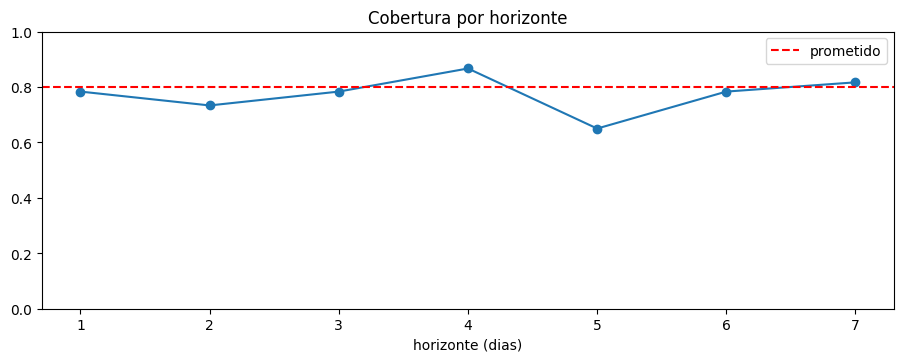

In [ ]:
por_h = ev.groupby("h")[["target"] + QC].apply(cobertura).astype(float)

plt.plot(por_h.index.astype(int), por_h.values, marker="o")
plt.axhline(0.8, ls="--", c="r", label="prometido")
plt.ylim(0, 1); plt.xlabel("horizonte (dias)"); plt.title("Cobertura por horizonte"); plt.legend()
print(por_h.round(2).to_string())

* El promedio general (0.774) esconde que el día 1 está bien calibrado (0.78, mejor que lo prometido) mientras que el día 5 está muy mal calibrado (0.65, por debajo del 0.80 prometido).
* El gráfico muestra la caída de los calibres con una línea roja horizontal en 0.80 como referencia: vamos a ver los puntos empezar cerca de la línea y alejarse hacia abajo a medida que crece el horizonte.

* Esto es un patrón típico: cuanto más lejos predecimos, peor calibrado está el modelo porque subestima cuánto crece la incertidumbre real.



### 4b El histograma PIT, el diagnóstico

* Para cada predicción, cuenta en cuántos de los 9 cuantiles el valor real quedó "por encima", y lo convierte en una proporción entre 0 y 1. Esto es esencialmente "¿en qué percentil aproximado cayó el valor real, según el propio modelo?".
* Si el modelo es honesto, estos percentiles deberían distribuirse uniformemente entre 0 y 1 (porque, en promedio, un valor real cae en cualquier percentil con igual probabilidad).

* Si el modelo es honesto, esos niveles se reparten parejo, histograma plano.

23% en los extremos (lo ideal es 20%)


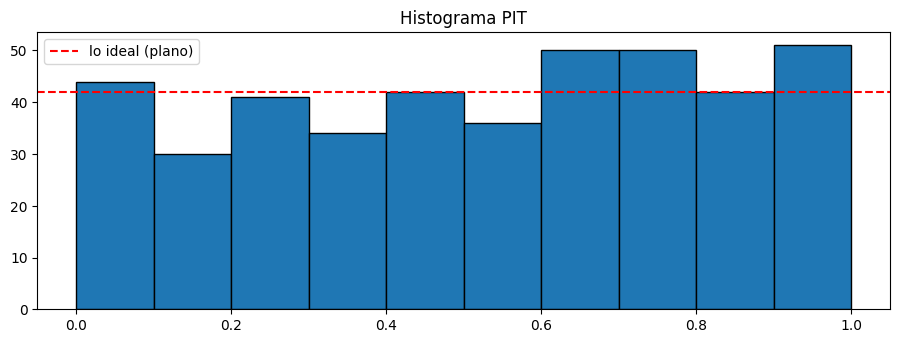

In [ ]:
pit = (ev[QC].values < ev.target.values[:, None]).mean(axis=1)

plt.hist(pit, bins=10, edgecolor="k")
plt.axhline(len(pit) / 10, ls="--", c="r", label="lo ideal (plano)")
plt.title("Histograma PIT"); plt.legend();

print(f"{((pit < 0.1) | (pit > 0.9)).mean():.0%} en los extremos (lo ideal es 20%)")

Cómo leerlo:

* Plano: el modelo es honesto.
* Forma de U: rangos muy angostos (el caso encontrado acá).
* Joroba al medio: rangos demasiado anchos (el modelo es "demasiado cauteloso").
* Inclinado hacia un lado: hay sesgo sistemático, primero hay que arreglar la predicción central antes de preocuparse por el ancho del rango.

### 4c. Pinball y CRPS

In [ ]:
def pinball(y, q, tau):
    d = y - q
    return np.maximum(tau * d, (tau - 1) * d)

# ejemplo suelto: nivel 90, predije 300, salio 400
print("nivel 90, me quede corto por 100 ->", pinball(400, 300, 0.9))
print("nivel 90, me pase por 100 ->", pinball(200, 300, 0.9))

# CRPS = pinball promediada sobre todos los niveles, x2
crps = 2 * np.mean([pinball(ev.target.values, ev[str(q)].values, q).mean() for q in QL])
mae  = np.abs(ev.target - ev["0.5"]).mean()
print(f"\nMAE  = {mae:.0f}   (que tan lejos estuvo el numero)")
print(f"CRPS = {crps:.0f}   (que tan lejos estuvo el abanico)")

nivel 90, me quede corto por 100 -> 90.0
nivel 90, me pase      por 100 -> 9.999999999999998

MAE  = 832   (que tan lejos estuvo el numero)
CRPS = 661   (que tan lejos estuvo el abanico)


* El MAE mide qué tan lejos estuvo la mediana del valor real (el error "puntual" clásico).
* El CRPS mide qué tan bien calibrado estuvo el abanico completo de incertidumbre.
* Comparar ambos nos da una foto más completa: podemos tener un buen MAE (predicciones puntuales razonables) pero un mal CRPS (el rango de incertidumbre alrededor de esa predicción está mal calibrado).

---
## E) Arreglarlo: conformal prediction

Este bloque hace lo siguiente:

1. Para cada corte de tiempo, mira las últimas 15 ventanas anteriores (no todo el historial, para adaptarse a cambios de escala en la demanda).
2. Calcula el error relativo histórico: qué tan lejos estuvo la mediana predicha del valor real, en esas 15 ventanas, expresado como porcentaje del valor predicho.
3. Toma el percentil 80 de esos errores históricos (q), esto responde "¿qué tan grande tiene que ser el margen para que el 80% de mis errores pasados hubieran quedado adentro?"
4. Construye un nuevo rango [mediana × (1-q), mediana × (1+q)] usando ese margen empírico, en vez de confiar en los cuantiles que el modelo generó internamente.

Es decir: en vez de preguntarle al modelo "¿qué tan seguro estás?", el método le dice "no te pregunto, yo mido cuánto te equivocaste en el pasado reciente y te construyo el margen basado en eso".

In [ ]:
def conformal(ev, nivel=0.8, K=15):
    cortes, out = np.sort(ev.cutoff.unique()), []
    for c in cortes[K:]:
        previas = np.sort(ev[ev.cutoff < c].cutoff.unique())[-K:]
        cal = ev[ev.cutoff.isin(previas)]

        s = ((cal.target - cal["0.5"]).abs() / cal["0.5"].abs()).values   # error relativo
        q = np.quantile(s, min(nivel * (len(s) + 1) / len(s), 1.0))       # el percentil 80

        g = ev[ev.cutoff == c].copy()
        g["lo_c"], g["hi_c"] = g["0.5"] * (1 - q), g["0.5"] * (1 + q)
        out.append(g)
    return pd.concat(out, ignore_index=True)

t = conformal(ev)

print("                  cobertura   ancho medio")
print(f"sin corregir        {cobertura(t):.3f}      {(t['0.9']-t['0.1']).mean():.0f}")
print(f"con conformal       {cobertura(t,'lo_c','hi_c'):.3f}      {(t.hi_c-t.lo_c).mean():.0f}")
print(f"prometido           0.800")

                  cobertura   ancho medio
sin corregir        0.778      2757
con conformal       0.794      2877
prometido           0.800


Chronos-2, en zero-shot y sin ningún ajuste, ya viene razonablemente bien calibrado para esta serie. Conformal prediction actuó más como un afinador fino que como una corrección drástica.

El ancho del intervalo apenas creció: de 2757 a 2877, un aumento de solo el 4.3%. Acá, como el modelo ya estaba casi bien calibrado, conformal no tuvo que "inflar" mucho el rango para arreglarlo.

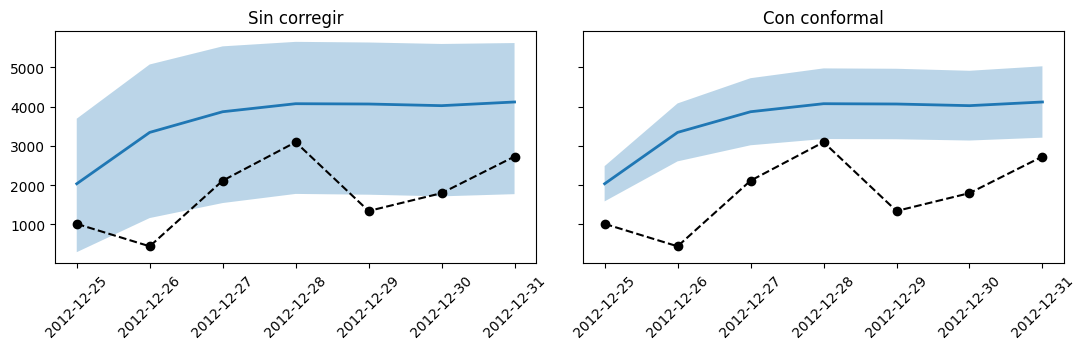

In [ ]:
u = t[t.cutoff == t.cutoff.max()]
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(11, 3.6))
for a, (lo, hi, tit) in zip(ax, [("0.1","0.9","Sin corregir"), ("lo_c","hi_c","Con conformal")]):
    xs = u.timestamp.values
    a.fill_between(xs, u[lo], u[hi], alpha=.3)
    a.plot(xs, u["0.5"], lw=2)
    a.plot(xs, u.target.values, "ko--")
    a.set_title(tit); a.tick_params(axis="x", rotation=45)
plt.tight_layout();

## F) Del rango a la decisión

Volvemos a la pregunta del principio: **¿cuántas bicis pongo disponibles?**

In [ ]:
def costo(y, q, c_faltar, c_sobrar):
    return np.where(y > q, c_faltar * (y - q), c_sobrar * (q - y)).mean()

escenarios = [
    ("faltar cuesta 9x mas", 9, 1),
    ("cuesta igual",         1, 1),
    ("sobrar cuesta 4x mas", 1, 4),
]

for nombre, cu, co in escenarios:
    nivel_opt = cu / (cu + co)
    col = min(QC, key=lambda c: abs(float(c) - nivel_opt))
    print(f"\n{nombre}  ->  nivel optimo {nivel_opt:.2f}")
    for c in QC:
        marca = "  <-- optimo" if c == col else ""
        print(f"    decidir con nivel {float(c)*100:>2.0f}: costo {costo(ev.target.values, ev[c].values, cu, co):8.0f}{marca}")


faltar cuesta 9x mas  ->  nivel optimo 0.90
    decidir con nivel 10: costo    13910
    decidir con nivel 20: costo     9136
    decidir con nivel 30: costo     6535
    decidir con nivel 40: costo     4907
    decidir con nivel 50: costo     3769
    decidir con nivel 60: costo     2887
    decidir con nivel 70: costo     2249
    decidir con nivel 80: costo     1798
    decidir con nivel 90: costo     1602  <-- optimo

cuesta igual  ->  nivel optimo 0.50
    decidir con nivel 10: costo     1638
    decidir con nivel 20: costo     1182
    decidir con nivel 30: costo      969
    decidir con nivel 40: costo      869
    decidir con nivel 50: costo      832  <-- optimo
    decidir con nivel 60: costo      837
    decidir con nivel 70: costo      886
    decidir con nivel 80: costo     1005
    decidir con nivel 90: costo     1233

sobrar cuesta 4x mas  ->  nivel optimo 0.20
    decidir con nivel 10: costo     1949
    decidir con nivel 20: costo     1746  <-- optimo
    decidir con n

**Escenario 1**

* El costo cae de manera monótona y constante a medida que subimos el nivel de decisión, desde 13910 hasta 1602.
* Tiene sentido: si faltar es carísimo (9 veces más caro que sobrar), la estrategia ganadora es poner de más siempre, así que cuanto más alto el cuantil que usemos para decidir, menor el costo.
* El mínimo cae exactamente en el nivel 90, que es el límite superior de los cuantiles que pediste (0.1 a 0.9) y coincide con el óptimo teórico de 0.90. Si hubieras pedido un cuantil 0.95 probablemente el costo seguiría bajando un poco más, pero dentro del menú disponible, el 90 es literalmente el mejor.

**Escenario 2**
* Acá la forma es distinta: es una curva en forma de U, bajando hasta un mínimo y después volviendo a subir. Esto tiene sentido porque ahora ni faltar ni sobrar es peor que lo otro, el costo mínimo esperado se da usando la mediana (nivel 50)
* El mínimo es muy plano: 832 en el nivel 50 contra 837 en el nivel 60, apenas 5 unidades de diferencia. Eso es esperable, cerca del óptimo, la función de costo es relativamente chata (es una propiedad de la pinball loss).

**Escenario 3**
* De nuevo forma de U, pero ahora el mínimo se corrió hacia la izquierda, al nivel 20.
* Tiene sentido: si sobrar es lo caro, conviene pecar de quedarse corto en el inventario (poner menos bicis de las que probablemente hagan falta), porque el costo de que sobren unidades pesa mucho más que el de que falten. El mínimo exacto (1746) cae justo en el nivel 20.